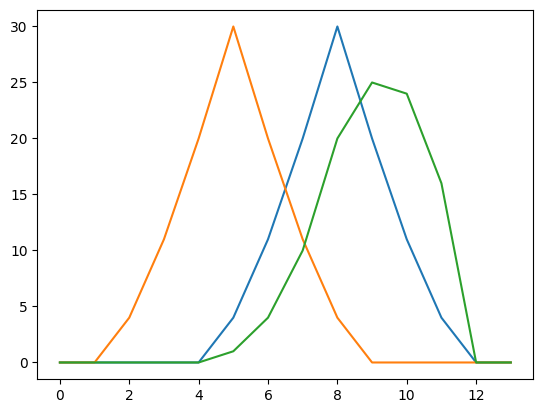

In [1]:
import scipy
import matplotlib.pyplot as plt
import numpy as np
arr1= [0,0,0,0,0,1,2,3,4,0,0]
arr2= [1,2,3,4]
arr3= np.flip(arr2)
cross_corr = scipy.signal.correlate(arr1,arr2, mode='full', method='auto')
plt.plot( cross_corr)
cross_corr_2 = scipy.signal.correlate(arr2,arr1, mode='full', method='auto')
plt.plot( cross_corr_2)
cross_corr_3 = scipy.signal.correlate(arr1,arr3, mode='full', method='auto')
plt.plot( cross_corr_3)


### conclusion:

the correlation function does indeed do the correlation the right way round - lovely

In [ ]:
def prepare_tx_sequence(plot = False) -> dict:
    # ------------- build pieces -------------
    silence     = np.zeros(int(SILENCE_LEN_S * FS), np.float32)
    chirp_up    = generate_chirp(F0, F1, CHIRP_LEN_S)
    chirp_down  = add_cyclic_prefix(generate_chirp(F1, F0, CHIRP_LEN_S))


    # ------------- build data blocks, returns data_blocks 2D array -------------
    long_bits = random_bits(n = (TX_REPS * (FFT_LEN + CP_LEN)), seed_no=24)
    data_blocks = []
    for i in range(TX_REPS):
        bits = long_bits[i * n_qpsk : (i + 1) * n_qpsk]
        syms, _ = qpsk_gray(bits)
        block = add_cyclic_prefix(to_real_ofdm_block(syms))
        data_blocks.append(block)
    np.save(DATA_NPY, data_blocks)

    # ------------- build pilot blocks, returns pilot ------------
    n_qpsk = FFT_LEN//2 - 1
    pilot_bits = random_bitpairs(n_qpsk)
    pilot, colour = qpsk_gray(pilot_bits)            
    np.save(COLMAP_NPY, colour)                   
    np.save(PILOT_NPY, pilot)

    
    # ------------- build sequence -------------
    payload = []
    for i in range(TX_REPS):
        payload.append(pilot)
        payload.append(data_blocks[i])


    sequence = np.concatenate([
        silence,
        chirp_up,
        *payload,  # interleave pilot and data blocks
        chirp_down
    ])

    sequence_with_prefix = np.vstack([
        sequence[0],  # first block (e.g., chirp_up) stays unchanged
        *[add_cyclic_prefix(block) for block in sequence[1:]]
    ])
# ------------- plot function -------------
    if plot:
        plt.figure(figsize=(10, 3))
        plt.plot(sequence, lw=0.7)
        plt.title("Transmit waveform (time domain)")
        plt.xlabel("sample")
        plt.ylabel("amplitude")
        plt.tight_layout()
        plt.show()

# ------------- flat dictionary -------------
    info = {
        "leading_silence_samples": len(silence),
        "chirp_samples"          : len(chirp_up),
        "ofdm_block_len"         : len(blk_td),
        "ofdm_block_len_with_cp" : len(add_cyclic_prefix(blk_td)),
        "cp_len"                 : CP_LEN,
        "block_real?"            : np.isrealobj(blk_td),
        "total_ofdm_length"      : len(sequence) - len(chirp_up) - len(add_cyclic_prefix(chirp_down)) - len(silence),
        "final_len"              : len(sequence)
    }
    return { "waveform": sequence, **info}

### linspace experiments

In [6]:
t = np.linspace(0, 27, 10, endpoint=False)
print(t)
t = np.linspace(0, 27, 10, endpoint=True)
print(t)

[ 0.   2.7  5.4  8.1 10.8 13.5 16.2 18.9 21.6 24.3]
[ 0.  3.  6.  9. 12. 15. 18. 21. 24. 27.]


### list insertion experiments

In [2]:
import numpy as np
list = np.zeros(10)
list[[1, 3]] = [4, 6]
print(list)

[0. 4. 0. 6. 0. 0. 0. 0. 0. 0.]


In [13]:
import numpy as np
mylist = np.zeros(10)
mylist[[1, 3]] = [4, 6]
np.array(mylist)

big_list = np.array([list, [1, 2, 3]], dtype=object)

print(big_list)

[array([0., 4., 0., 6., 0., 0., 0., 0., 0., 0.]) list([1, 2, 3])]


In [ ]:
def ofdm_blocks(payload):
    blocks, idx = [], 0  # idx = index
    for _ in range(5):
        blocks.append(payload[idx:idx+FFT_LEN+CP_LEN]); idx += FFT_LEN + CP_LEN  # !make a more robust function that can handle blocks with cyclic prefixes throughout
        blocks[-1] = blocks[-1][CP_LEN:]  # remove cyclic prefix
    return np.array(blocks)

def time_OFDM_blocks(payload, block_length_time = output["ofdm_block_len_with_cp"]):
    time_blocks = []
    if len(payload)%block_length_time != 0:
        raise ValueError("Payload length is not a multiple of block length.")
    for i in range(len(payload)//block_length_time - 0):
        i = i # allows for future non prefixed code at the beginning of the payload
        time_blocks.append(payload[i*block_length_time:(i+1)*block_length_time])
        time_blocks[-1] = time_blocks[-1][CP_LEN:]

    return np.array(time_blocks)



In [14]:
for i in range(5):
    print(i)

0
1
2
3
4


In [ ]:
def channel_estimate(useful_frequency_blocks:np.ndarray, #we're going to need an extra input to measure SNR
                     pilot:np.ndarray, 
                     method:str='zf',            
                     noise_var:float=1e-4) -> np.ndarray:
    
    eps = 1e-12
    H_list = []  # list to store channel estimates for each block
    for i in useful_frequency_blocks:
        if method.lower() == 'mmse':                   
            H_zf  = i / (pilot + eps)
            Rhh   = np.mean(np.abs(H_zf)**2)
            H_hat = (Rhh / (Rhh + noise_var)) * H_zf

        else:                                           
            H_hat = i / (pilot + eps)
        H_list.append(H_hat) # append each channel estimate to a list
    H_list_pilot = H_list[0:1]+H_list[3:4]
    H_hat_av = np.mean(H_list_pilot, axis=1)
    np.save(CHAN_NPY, H_hat_av)
    return H_hat



def channel_estimate(useful_frequency_blocks: np.ndarray, pilot_symbols: np.ndarray, payload_type_list: list[str], method: str = 'zf',noise_var: float = 1e-4) -> np.ndarray:

    eps = 1e-12
    averaged_channel_estimates = []

    def estimate_block(freq_block):
        h_zf = freq_block / (pilot_symbols + eps)
        # if method.lower() == 'mmse':
        #     Rhh = np.mean(np.abs(h_zf)**2)
        #     return (Rhh / (Rhh + noise_var)) * h_zf
        return h_zf

    # Pre-compute estimates for all pilot blocks
    pilot_estimates = [estimate_block(freq_block) for freq_block, btype in zip(useful_frequency_blocks, payload_type_list) if btype == 'pilot']

    # Iterate and estimate for data blocks based on nearby pilots
    for idx, btype in enumerate(payload_type_list):
        if btype == 'data':
            # Find surrounding pilot indices
            prev_pilot = next((j for j in range(idx - 1, -1, -1) if payload_type_list[j] == 'pilot'), None)
            next_pilot = next((j for j in range(idx + 1, len(payload_type_list)) if payload_type_list[j] == 'pilot'), None)

            # Get channel estimates from pilot blocks
            averaged_channel_estimates = []
            if prev_pilot is not None:
                averaged_channel_estimates.append(estimate_block(useful_frequency_blocks[prev_pilot]))
            if next_pilot is not None:
                averaged_channel_estimates.append(estimate_block(useful_frequency_blocks[next_pilot]))

            avg_est = np.mean(averaged_channel_estimates, axis=0)
            averaged_channel_estimates.append(avg_est)

    H_est_array = np.array(averaged_channel_estimates)
    np.save(CHAN_NPY, H_est_array)
    return H_est_array



def initial_channel_estimate(useful_frequency_blocks:np.ndarray, #we're going to need an extra input to measure SNR
                     pilot:np.ndarray, 
                     method:str='zf',            
                     noise_var:float=1e-4) -> np.ndarray:
    
    eps = 1e-12
    H_list = []  # list to store channel estimates for each block
    for i in useful_frequency_blocks:
        if method.lower() == 'mmse':                   
            H_zf  = i / (pilot + eps)
            Rhh   = np.mean(np.abs(H_zf)**2)
            H_hat = (Rhh / (Rhh + noise_var)) * H_zf

        else:                                           
            H_hat = i / (pilot + eps)
        H_list.append(H_hat) # append each channel estimate to a list
    H_list_pilot = H_list[0:1]+H_list[3:4]
    H_hat_av = np.mean(H_list_pilot, axis=1)
    np.save(CHAN_NPY, H_hat_av)
    return H_hat

In [ ]:
def plot_constellation_blocks(decoded_blocks, indices=None):
    """
    Plot constellation points for one or multiple decoded OFDM data blocks.

    Parameters:
    - decoded_blocks: np.ndarray or list/array of np.ndarrays
        Equalised frequency-domain decoded blocks to plot.
    - indices: list[int] or None
        Optional indices specifying which blocks to plot (if decoded_blocks is a list).
        If None, plots all blocks if input is a list, or the single block if input is an array.

    Behavior:
    - Normalizes each block to unit power.
    - Cycles through a base color map loaded from COLMAP_NPY for points.
    - Adds a legend showing the symbol mapping if available.
    """
    # Make sure decoded_blocks is a list of arrays
    if isinstance(decoded_blocks, np.ndarray) and decoded_blocks.ndim > 1:
        # Already a 2D array, treat as one block
        blocks_to_plot = [decoded_blocks]
    else:
        # Assume list-like or 1D array of blocks
        blocks_to_plot = list(decoded_blocks)

    if indices is not None:
        blocks_to_plot = [blocks_to_plot[i] for i in indices]

    # Load base colors
    base_colors = np.load(COLMAP_NPY, allow_pickle=True)
    if base_colors.ndim == 1 and len(base_colors) == 1 and isinstance(base_colors[0], (list, np.ndarray)):
        base_colors = np.asarray(base_colors[0], dtype=str)
    base_colors = np.asarray(base_colors, dtype=str)
    if base_colors.size == 0:
        base_colors = np.array(['k'])

    plt.figure()
    plt.axhline(0, c='k'); plt.axvline(0, c='k')

    # Plot each block with cyclic colors
    for block_idx, block in enumerate(blocks_to_plot):
        block = np.asarray(block).ravel()
        # Normalize block power to unit power
        norm_block = block / (np.sqrt(np.mean(np.abs(block)**2)) + 1e-12)
        reps = int(np.ceil(norm_block.size / base_colors.size))
        colors = np.tile(base_colors, reps)[:norm_block.size]

        plt.scatter(norm_block.real, norm_block.imag, c=colors, s=12, alpha=0.8, label=f"Block {indices[block_idx] if indices else block_idx}")

    # Legend setup, if transmitter color map is available
    try:
        from transmitter_00_02 import Q_COL
        colour_map = {v: k for k, v in Q_COL.items()}  # color to bits mapping
        label_map = {'00': '1+1j', '01': '1-1j', '11': '-1-1j', '10': '-1+1j'}
        unique_colors = np.unique(base_colors)
        legend_elements = []
        for c in unique_colors:
            bits = ''.join(map(str, colour_map.get(c, ('?','?'))))
            legend_elements.append(Patch(facecolor=c, label=label_map.get(bits, bits)))
        plt.legend(handles=legend_elements, loc='upper right', fontsize='small')
    except ImportError:
        pass  # no transmitter module, skip legend

    plt.title("Equalised constellation (unit power)")
    plt.xlabel("In-phase (I)")
    plt.ylabel("Quadrature (Q)")
    plt.gca().set_aspect('equal')
    plt.tight_layout()
    plt.show()



"""
1. pass in equalised data blocks (output of reconstruct_data_blocks() function)
2. make a colour vector for each ideal data block from the transmitter(add in data_blocks frequency domain, an array defined by output["payload_data_blocks"] + use COLMAP_NPY)
3. plot each equalised data block with the corresponding colour vector
4. add a legend telling you which colour corresponds to which symbol
5. find the mean value of each colour and plot that on the constellation plot as well
"""


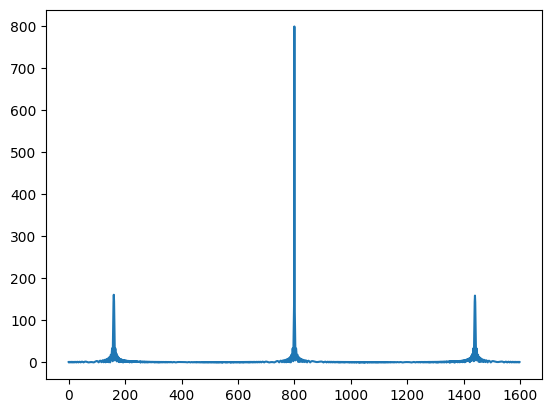

In [ ]:
import scipy

import numpy as np

import matplotlib.pyplot as plt
k = 1000
f0 = 20
T = 0.5
N = 1000
t = np.linspace(-T, T, 2 * N, endpoint=False)
anti_chirp = np.exp(1j * (2 * np.pi * f0 * t - np.pi * k * t**2))
chirp = np.exp(1j * (2 * np.pi * f0 * t + np.pi * k * t**2))
function  = scipy.signal.convolve(chirp, anti_chirp, mode='full', method='auto')
plt.plot(np.abs(function))
